In [1]:
import os

import ast
import pandas as pd
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport
import re

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
PATH_OUT = r'D:\code_files\Python\data_analysis_yandex\yandex_final\git\SADTeam\Настя'

In [3]:
df = pd.read_csv(PATH_OUT + '\\rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0


In [4]:
df1 = df.copy()
df2 = df.copy()

In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


In [6]:
df2.dropna(subset=['Start Date', 'End Date'], inplace=True)
df2["Distance"].isna().sum()
df2.dropna(subset=["Distance"], inplace=True)
df2['Start Date'] = pd.to_datetime(df2['Start Date'])
df2['End Date'] = pd.to_datetime(df2['End Date'])
df2.dropna(subset=['Start Date', 'End Date'], inplace=True)

df2[df2.isnull().any(axis=1)]
#print(df2.isnull().sum())
#df2[df2.isnull().any(axis=1)]
df2

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0


In [7]:
def normalize_street_name(name):
    if pd.isna(name):
        return name

    name = str(name).strip().lower()  # всё сразу в нижний регистр

    # Удаляем существующие префиксы
    if name.startswith(('ул.', 'ул ')):
        parts = name.split(maxsplit=1)
        name = parts[1] if len(parts) > 1 else ''

    name = name.replace('.', '').strip()

    if not name:
        return np.nan

    return f'ул. {name}'  # всё в нижнем регистре

# Применяем к улицам
df2['Start Location'] = df2['Start Location'].apply(normalize_street_name)
df2['End Location'] = df2['End Location'].apply(normalize_street_name)

# Районы тоже в нижний регистр
df2['Start District'] = df2['Start District'].apply(lambda x: x.lower() if isinstance(x, str) else x)
df2['End District'] = df2['End District'].apply(lambda x: x.lower() if isinstance(x, str) else x)

df2['Start District'] = df2['Start District'].str.replace('северо западный', 'северо-западный')
df2['End District'] = df2['End District'].str.replace('северо западный', 'северо-западный')

df2['Start District'].unique()

array(['юго-восточный', 'заречный', 'октябрьский', 'центральный',
       'северо-западный', 'ленинский'], dtype=object)

In [8]:
df2['Start Month'] = df2['Start Date'].dt.month
df2['End Month'] = df2['End Date'].dt.month
seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}
df2['Start Season'] = df2['Start Month'].map(seasons)
df2['End Season'] = df2['End Month'].map(seasons)

df2['Time start'] = df2['Start Date'].dt.time
df2['Time end'] = df2['End Date'].dt.time
df2['Trip Duration'] = (df2['End Date'] - df2['Start Date']).dt.total_seconds() / 60

df2['Distance'] = pd.to_numeric(df2['Distance'], errors='coerce')
df2['Speed (km/h)'] = (df2['Distance'] / 1000) / (df2['Trip Duration'] / 60)

df2 = df2.copy()

#gap = df2['Distance'][df2['Distance'] > 3000000].count()

df2 = df2[df2['Distance'] < 1000000]
df2 = df2[df2['Speed (km/h)'] <= 50]
df2 = df2[df2['Distance'] <= 10000]

season_mapping = {"Весна": 1, "Лето": 2, "Осень": 3, "Зима": 4}
df22= df2.copy()
df22["Season_Num"] = df22["Start Season"].map(season_mapping)

correlation = df22["Trip Duration"].corr(df22["Season_Num"]) #пирсон
correlation1 = df22["Distance"].corr(df22["Season_Num"])

print(f"Корреляция между длительностью поездки и временем года: {correlation:.4f}")
print(f"Корреляция между длиной поездки и временем года: {correlation1:.4f}")

df2

Корреляция между длительностью поездки и временем года: -0.0010
Корреляция между длиной поездки и временем года: -0.0009


,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time start,Time end,Trip Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,4,Весна,Весна,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,4,Весна,Весна,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,09:09:27,09:40:07,30.666667,7.882826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,23:45:06,00:06:55,21.816667,9.081131
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,8,Лето,Лето,23:46:01,00:25:35,39.566667,7.570008
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,8,Лето,Лето,23:48:04,00:09:21,21.283333,7.839937
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,23:51:41,00:38:04,46.383333,8.364211


In [32]:
# Функция для распределения времени суток
def get_time_of_day(time):
    if time >= pd.to_datetime("06:00:00").time() and time < pd.to_datetime("12:00:00").time():
        return "Утро"
    elif time >= pd.to_datetime("12:00:00").time() and time < pd.to_datetime("18:00:00").time():
        return "День"
    elif time >= pd.to_datetime("18:00:00").time() and time < pd.to_datetime("00:00:00").time():
        return "Вечер"
    else:
        return "Ночь"

# Создаем новую колонку
df2["Time of Day"] = df2["Time start"].apply(get_time_of_day)

In [36]:
all_districts = pd.concat([
    df2['Start District'], 
    df2['End District']
]).unique()
# Создаем DataFrame с уникальными районами
districts_df = pd.DataFrame({'District': all_districts})

# Добавляем статистику по каждому району
districts_df['Start Count'] = districts_df['District'].apply(
    lambda x: df2[df2['Start District'] == x].shape[0])
districts_df['End Count'] = districts_df['District'].apply(
    lambda x: df2[df2['End District'] == x].shape[0])
districts_df['Total Trips'] = districts_df['Start Count'] + districts_df['End Count']

# Сортируем по количеству поездок
districts_df = districts_df.sort_values('Total Trips', ascending=False).reset_index(drop=True)

print(districts_df)

correlations_by_start_district = df2.groupby('Start District').apply(
    lambda x: x['Trip Duration'].corr(x['Distance'])
)
print(correlations_by_start_district)


          District  Start Count  End Count  Total Trips
0      центральный        25740      25068        50808
1    юго-восточный        18946      19354        38300
2  северо-западный        15894      16146        32040
3        ленинский        15936      16016        31952
4      октябрьский        13724      13958        27682
5         заречный         9583       9281        18864
Start District
заречный           0.567805
ленинский          0.587329
октябрьский        0.522128
северо-западный    0.597246
центральный        0.541846
юго-восточный      0.608538
dtype: float64


C:\Temp\ipykernel_12604\3493248591.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations_by_start_district = df2.groupby('Start District').apply(


In [70]:
rate_per_minute = 9
# Выделим день недели и час начала
df2['Weekday'] = df2['Start Date'].dt.weekday  # Понедельник = 0
df2['Start Hour'] = df2['Start Date'].dt.hour

# Условие: если понедельник, 6–9 часов включительно, и есть промо
condition_free_start = (
    (df2['Weekday'] == 0) &
    (df2['Start Hour'] >= 6) & (df2['Start Hour'] < 10) &
    (df2['Promo'] == 1)
)

# Применяем расчет стоимости
df2['Trip Cost'] = df2['Trip Duration'] * rate_per_minute  # без старта
df2.loc[~condition_free_start, 'Trip Cost'] += 30  # если не попадает под акцию, добавляем 30₽
df2

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,Start Season,End Season,Time start,Time end,Trip Duration,Speed (km/h),Weekday,Start Hour,Trip Cost,Time of Day
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,...,Весна,Весна,09:01:03,09:24:45,23.700000,10.301266,5,9,243.30,Утро
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,...,Весна,Весна,09:01:07,09:29:32,28.416667,9.533138,5,9,285.75,Утро
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,...,Весна,Весна,09:04:27,09:42:46,38.316667,7.077860,5,9,374.85,Утро
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,...,Весна,Весна,09:06:34,09:38:23,31.816667,7.318806,5,9,316.35,Утро
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,...,Весна,Весна,09:09:27,09:40:07,30.666667,7.882826,5,9,306.00,Утро
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,...,Лето,Лето,23:45:06,00:06:55,21.816667,9.081131,0,23,226.35,Ночь
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,...,Лето,Лето,23:46:01,00:25:35,39.566667,7.570008,0,23,386.10,Ночь
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,...,Лето,Лето,23:48:04,00:09:21,21.283333,7.839937,0,23,221.55,Ночь
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,...,Лето,Лето,23:51:41,00:38:04,46.383333,8.364211,0,23,447.45,Ночь


In [72]:
# Группируем по району и признаку промо
promo_stats = df2.groupby(['Start District', 'Promo']).size().unstack(fill_value=0)
promo_stats.columns = ['Без промо', 'С промо']
promo_stats['Всего поездок'] = promo_stats['Без промо'] + promo_stats['С промо']

# Доля промо-поездок
promo_stats['Доля промо'] = promo_stats['С промо'] / promo_stats['Всего поездок']
promo_stats = promo_stats.sort_values(by='Доля промо', ascending=False)

promo_stats

,Без промо,С промо,Всего поездок,Доля промо
Start District,,,,
заречный,9364,219,9583,0.022853
северо-западный,15541,353,15894,0.022210
ленинский,15589,347,15936,0.021775
юго-восточный,18547,399,18946,0.021060
октябрьский,13444,280,13724,0.020402
центральный,25366,374,25740,0.014530


D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` varia

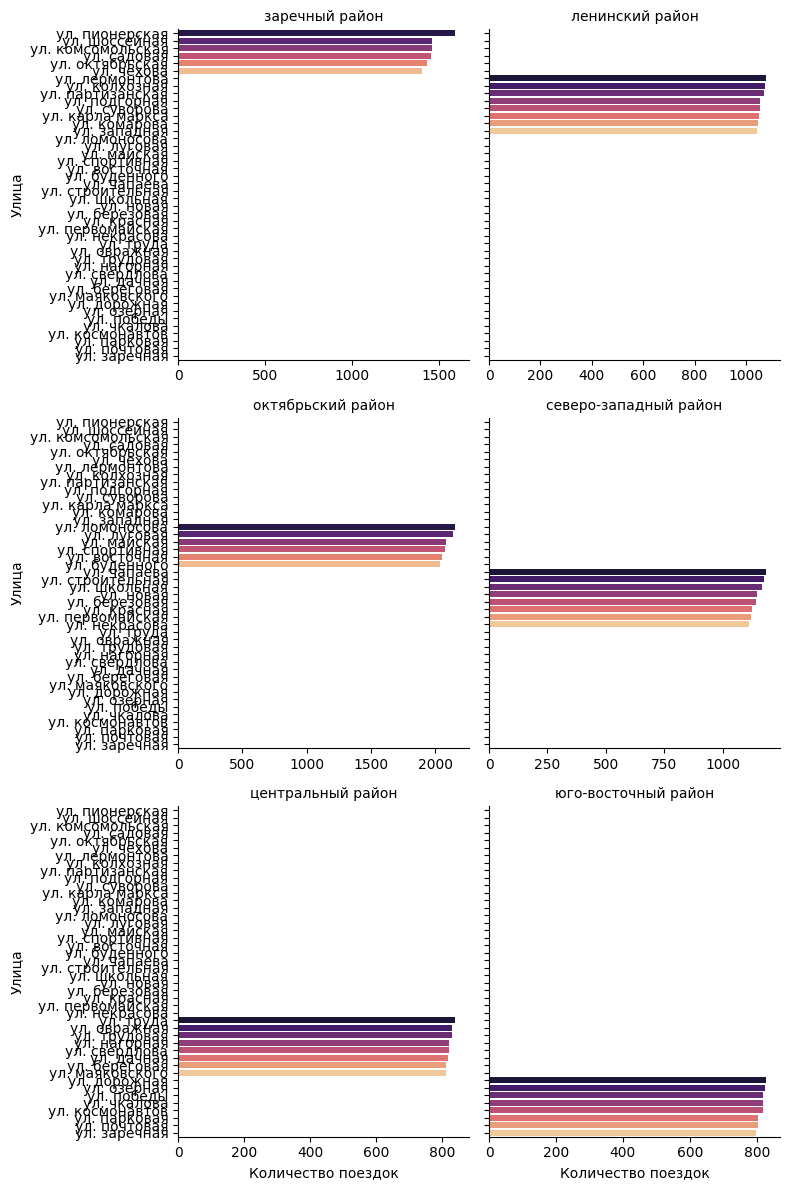

In [80]:
# Группируем по району и стартовой улице
street_distribution = df2.groupby(['Start District', 'Start Location']).size().reset_index(name='Поездок')

# Сортируем внутри каждого района по убыванию количества поездок
street_distribution = street_distribution.sort_values(['Start District', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('Start District').head(8),  # Топ-5 улиц на район
    col='Start District', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='Start Location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()


In [84]:
# Добавляем столбец, который будет указывать, является ли день выходным или будним
df2['Day Type'] = df2['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')

# Группируем данные по 'Day Type' и 'Start District', считаем количество поездок
district_day_type_distribution = df2.groupby(['Day Type', 'Start District']).size().reset_index(name='Количество поездок')

# Выводим таблицу распределения
print(district_day_type_distribution)

       Day Type   Start District  Количество поездок
0   Будний день         заречный                5878
1   Будний день        ленинский                9881
2   Будний день      октябрьский                8408
3   Будний день  северо-западный                9845
4   Будний день      центральный               16893
5   Будний день    юго-восточный               11848
6      Выходной         заречный                3705
7      Выходной        ленинский                6055
8      Выходной      октябрьский                5316
9      Выходной  северо-западный                6049
10     Выходной      центральный                8847
11     Выходной    юго-восточный                7098


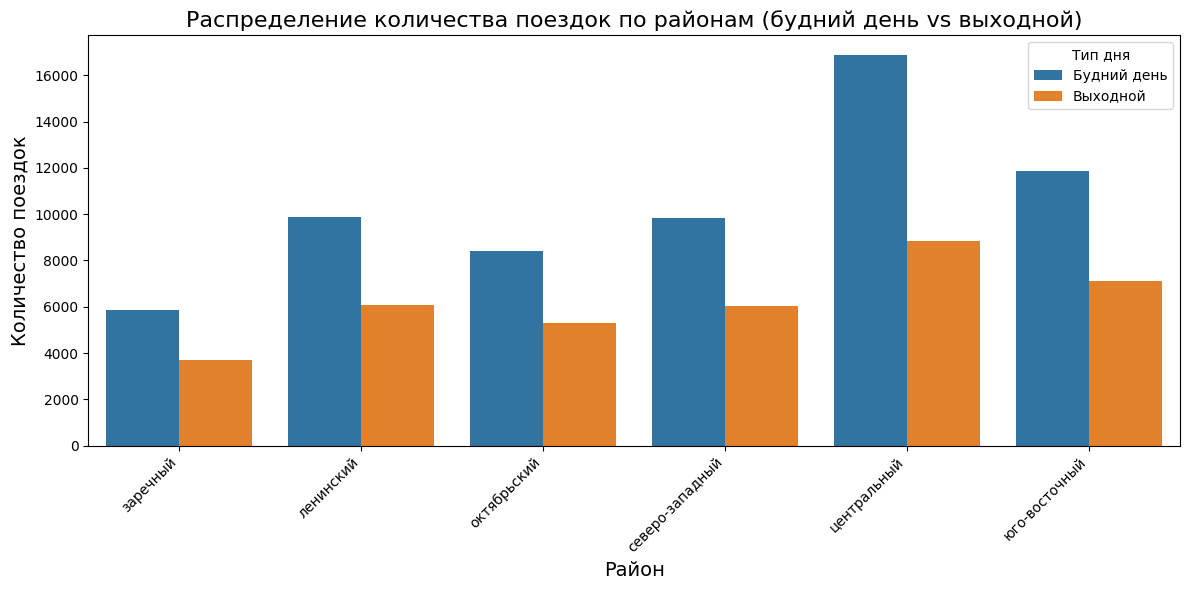

In [86]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Start District', y='Количество поездок', hue='Day Type', data=district_day_type_distribution)

# Настройки графика
plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

# Показываем график
plt.tight_layout()
plt.show()

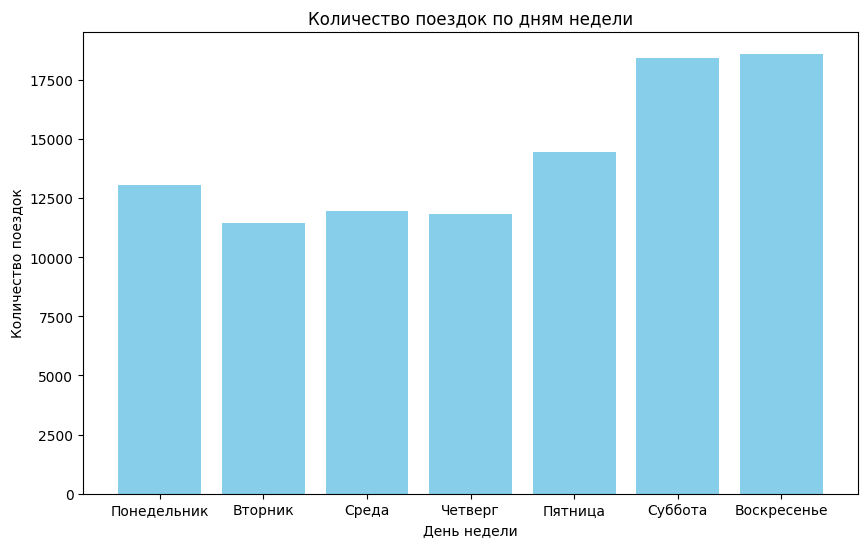

День недели с наибольшим количеством поездок: Воскресенье


In [88]:
weekday_counts = df2['Weekday'].value_counts().sort_index()

# Создаем график
plt.figure(figsize=(10, 6))
plt.bar(weekday_counts.index, weekday_counts.values, color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Количество поездок по дням недели')
plt.xticks(ticks=range(7), labels=['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье'])
plt.show()

# Выводим день недели с наибольшим количеством поездок
max_day = weekday_counts.idxmax()
print(f"День недели с наибольшим количеством поездок: {['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье'][max_day]}")

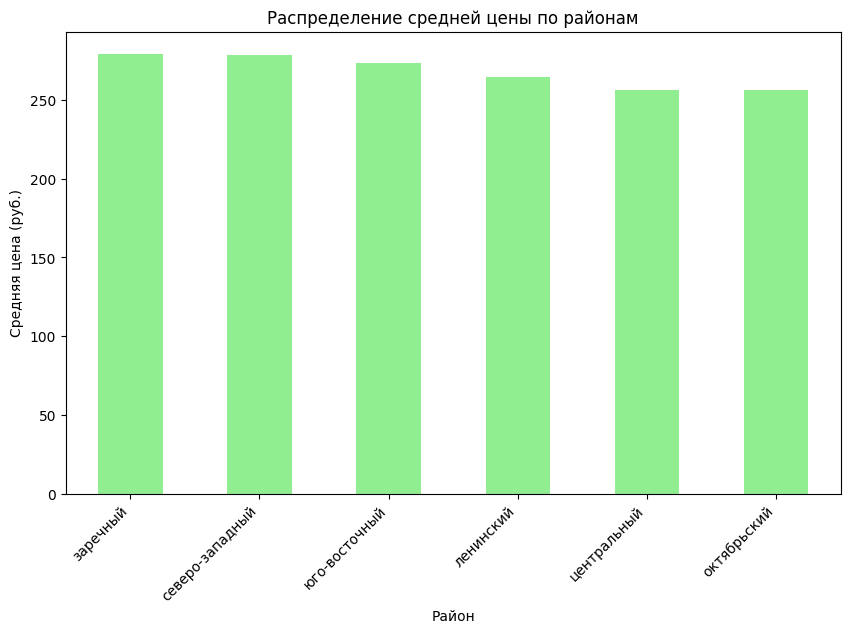

In [94]:
district_price = df2.groupby('Start District')['Trip Cost'].mean().sort_values(ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

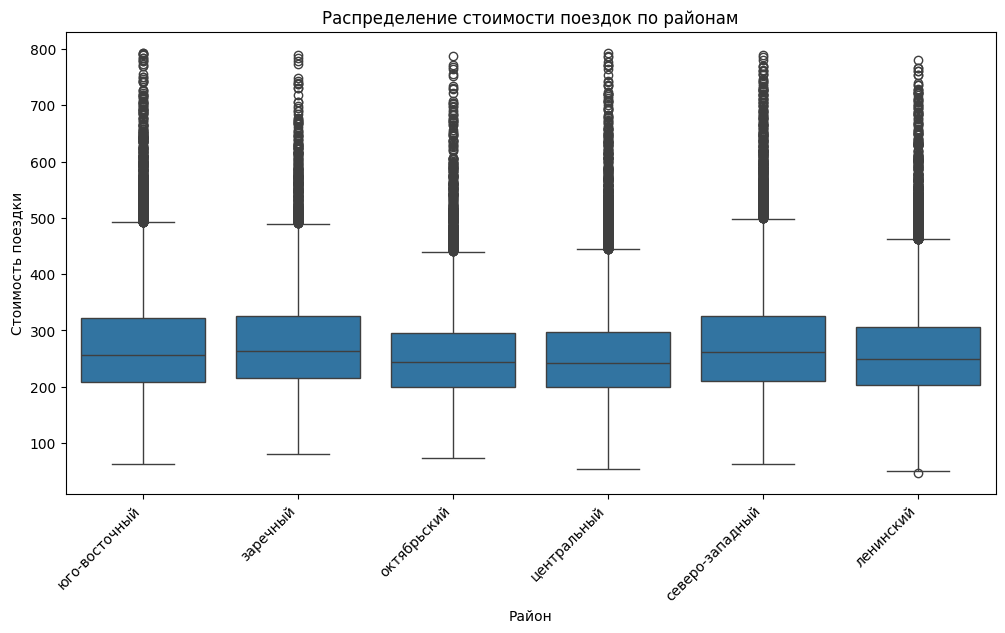

In [98]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Start District', y='Trip Cost', data=df2)

# Настроим график
plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Стоимость поездки')
plt.title('Распределение стоимости поездок по районам')

# Показываем график
plt.show()

In [100]:
print(df2['Trip Cost'].mean())
print(df2['Trip Cost'].max())

266.72196738226654
793.5


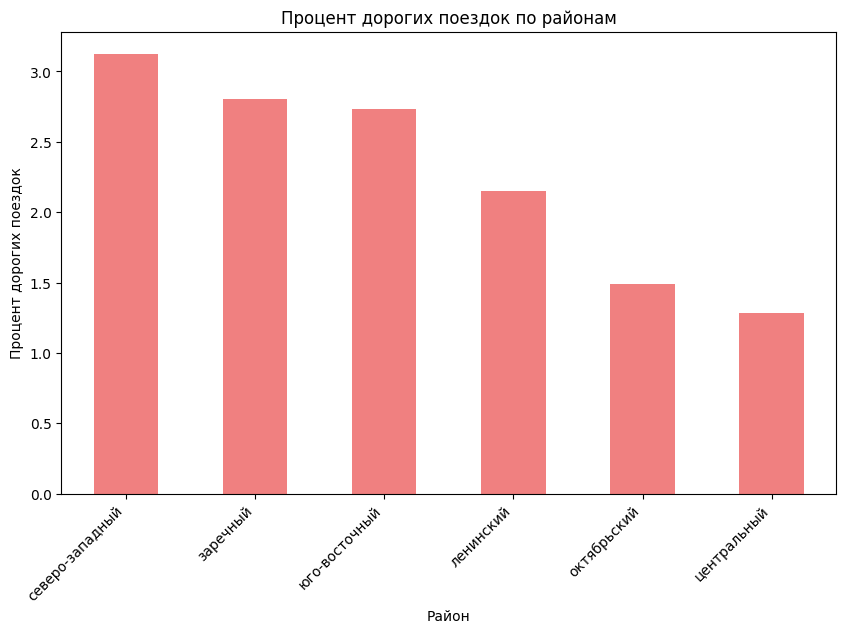

In [104]:
threshold = 500

# Рассчитываем, сколько поездок в каждом районе превышают этот порог
df2['Expensive Trip'] = df2['Trip Cost'] > threshold

district_expensive_percentage = df2.groupby('Start District')['Expensive Trip'].mean() * 100
district_expensive_percentage = district_expensive_percentage.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_expensive_percentage.plot(kind='bar', color='lightcoral')
plt.xlabel('Район')
plt.ylabel('Процент дорогих поездок')
plt.title('Процент дорогих поездок по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

C:\Temp\ipykernel_12604\1772200853.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")


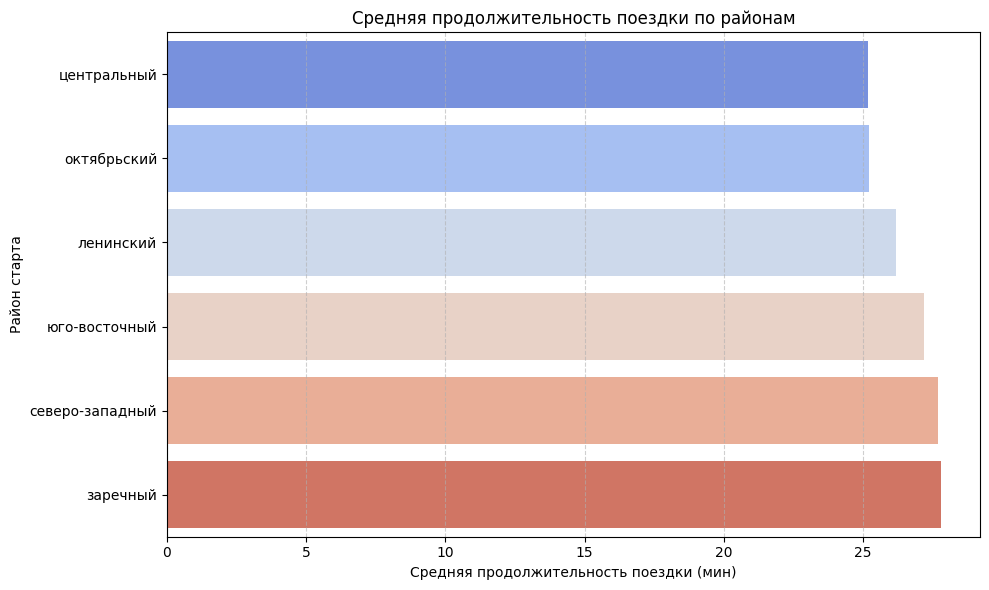

In [42]:
district_durations = df2.groupby("Start District")["Trip Duration"].mean().sort_values()

# Строим график
plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

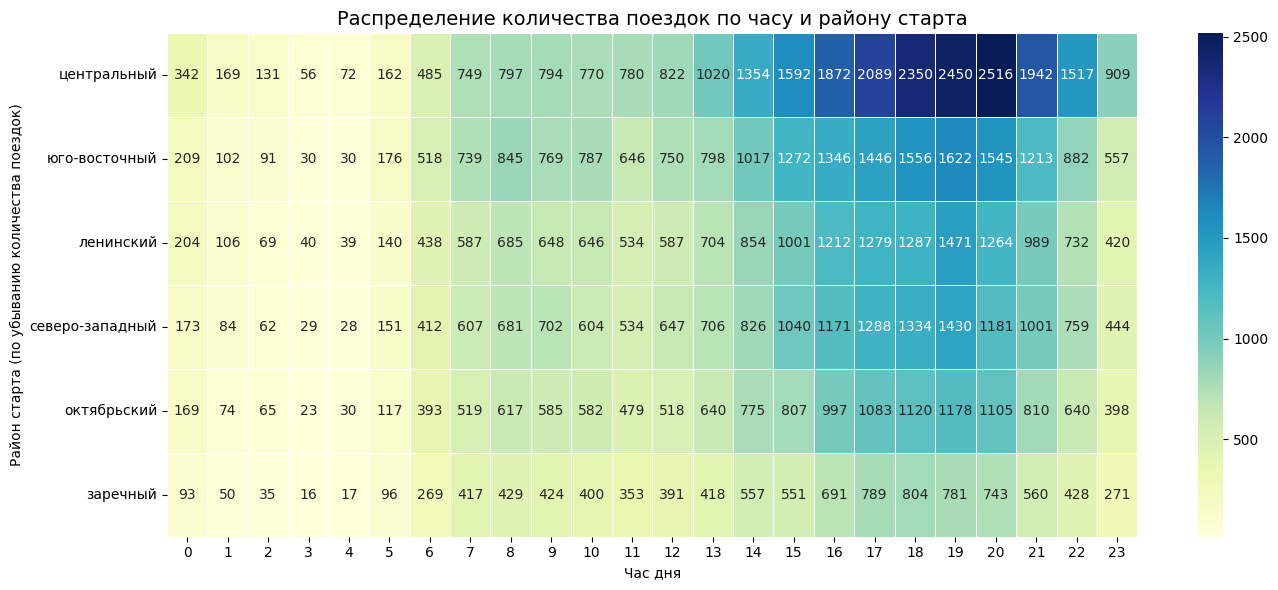

In [46]:
# Считаем общее количество поездок в каждом районе
district_order = df2['Start District'].value_counts().index.tolist()
# Преобразуем в формат таблицы
pivot_table = grouped.pivot(index='Start District', columns='Start Hour', values='Trip Count').fillna(0)

# Сортируем индексы по district_order
pivot_table = pivot_table.reindex(district_order)

# Строим график
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

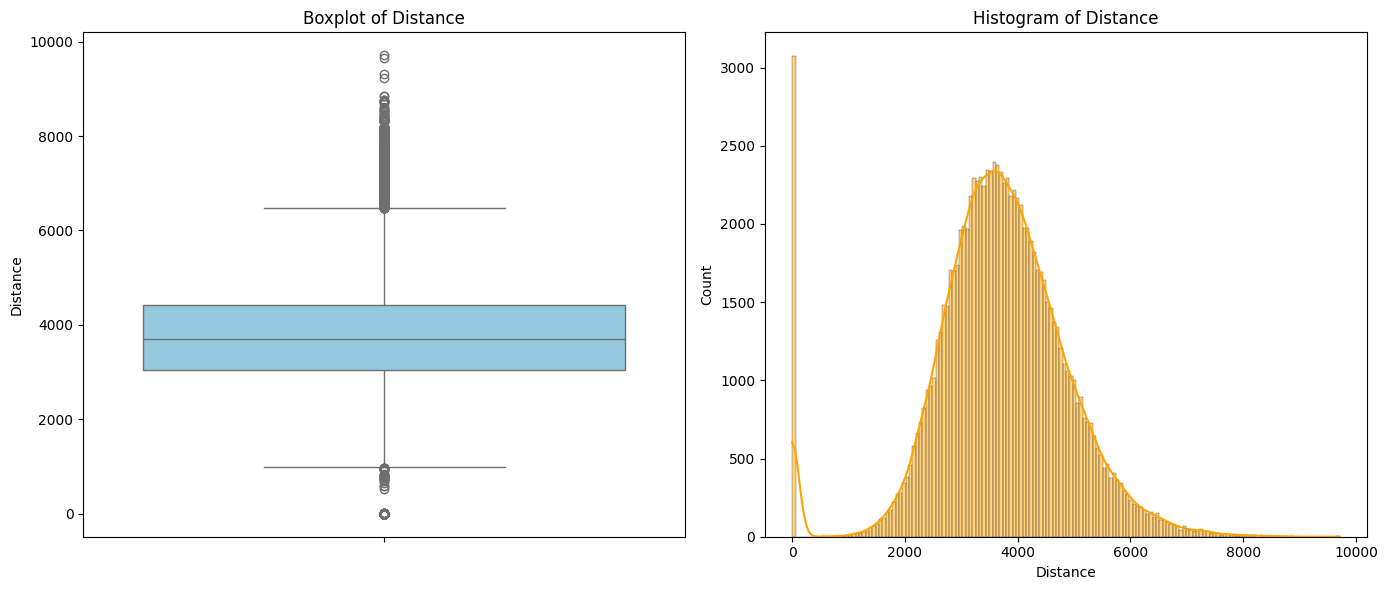

In [13]:
# Создаем графики в одном месте
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df2['Distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df2['Distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()

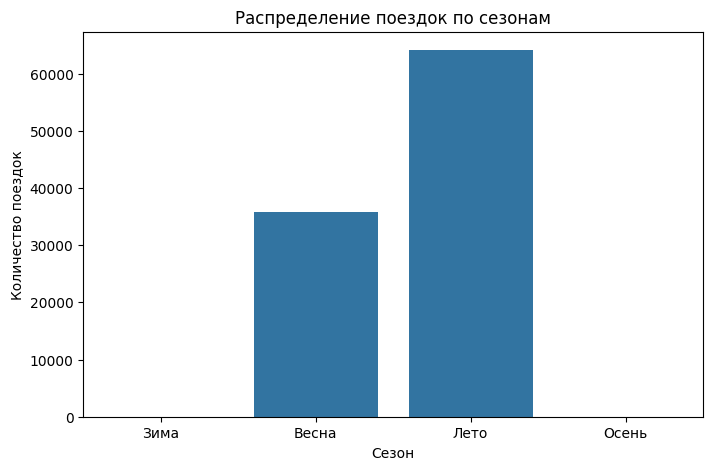

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Start Season', data=df2, order=['Зима', 'Весна', 'Лето', 'Осень'])
plt.title('Распределение поездок по сезонам')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.show()

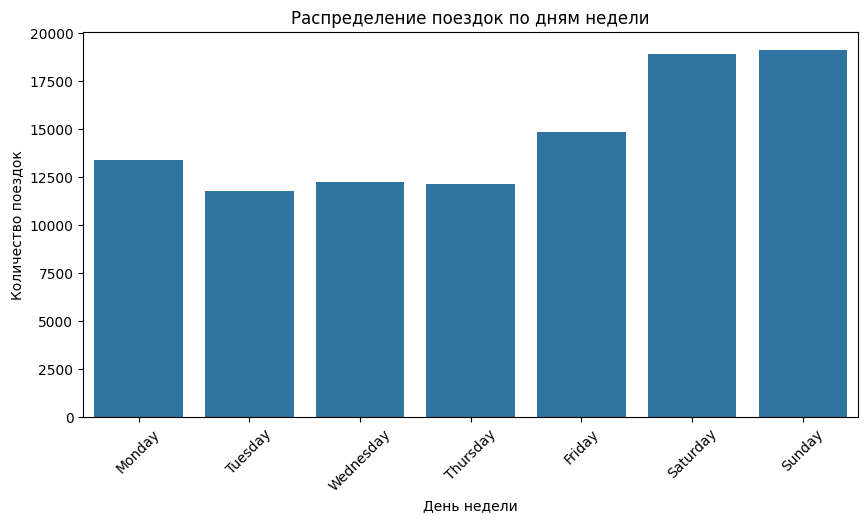

In [15]:
df["Start Date"] = pd.to_datetime(df["Start Date"])

# Добавляем колонку с днем недели
df["Day of Week"] = df["Start Date"].dt.day_name()

# Строим график
plt.figure(figsize=(10, 5))
sns.countplot(x=df["Day of Week"], order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.xticks(rotation=45)
plt.xlabel("День недели")
plt.ylabel("Количество поездок")
plt.title("Распределение поездок по дням недели")
plt.show()